In [3]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os
import cupy as cp

dtype = np.dtype([
    ('o', np.float32, 3),
    ('d', np.float32, 3),
    ('beta_before_rgb', np.float32, 3),
    ('L_after_rgb', np.float32, 3),
    ('T_after', np.float32, 3),
    ('tMax', np.float32, 1)
])

dtype_spectral = np.dtype([
    ('o', np.float32, 3),
    ('d', np.float32, 3),
    ('T_after_spectral', np.float32, 4),
    ('tMax', np.float32, 1)
])

print(os.getcwd())

/workspace/pbrt-v4-nn


In [4]:
with open("training_explosion.bin", "rb") as file:
    num_samples = np.frombuffer(file.read(8), dtype=np.uint64)[0]

    print(f"Number of samples: {num_samples}")
    num_samples = min(20000000, num_samples)
    data = np.frombuffer(file.read(), count=num_samples, dtype=dtype)


print(f"Loaded {len(data)} samples")

o_gpu = cp.asarray(data['o'])
d_gpu = cp.asarray(data['d'])
# t_after_spectral_gpu = cp.asarray(data['T_after_spectral'])
beta_gpu = cp.asarray(data['beta_before_rgb'])
# L_after_gpu = cp.asarray(data['L_after_rgb'])
T_after_gpu = cp.asarray(data['T_after'])
# tMax_gpu = cp.asarray(data['tMax'])
tMax_gpu = cp.asarray(data['tMax'])


Number of samples: 282979064
Loaded 20000000 samples


In [5]:
valid_mask = np.isfinite(data['tMax'].flatten())

valid_mask = cp.isfinite(tMax_gpu.flatten())
o_gpu = o_gpu[valid_mask]
d_gpu = d_gpu[valid_mask]
# t_after_spectral_gpu = t_after_spectral_gpu[valid_mask]
beta_gpu = beta_gpu[valid_mask]
# L_after_gpu = L_after_gpu[valid_mask]
T_after_gpu = T_after_gpu[valid_mask]
tMax_gpu = tMax_gpu[valid_mask]


print(f"Kept {len(o_gpu)} / {len(data)} samples")

Kept 20000000 / 20000000 samples


In [28]:

import random as rand

batch_size = 500000

indices = cp.random.choice(len(o_gpu), size=min(batch_size, len(o_gpu)), replace=False) + 100000


random_batch = {
    'o': o_gpu[indices],
    'd': d_gpu[indices],
    'beta': beta_gpu[indices],
    # 'L_after': L_after_gpu[indices],
    'T_after': T_after_gpu[indices],
    # 't_after': t_after_spectral_gpu[indices],
    'tMax': tMax_gpu[indices],
}


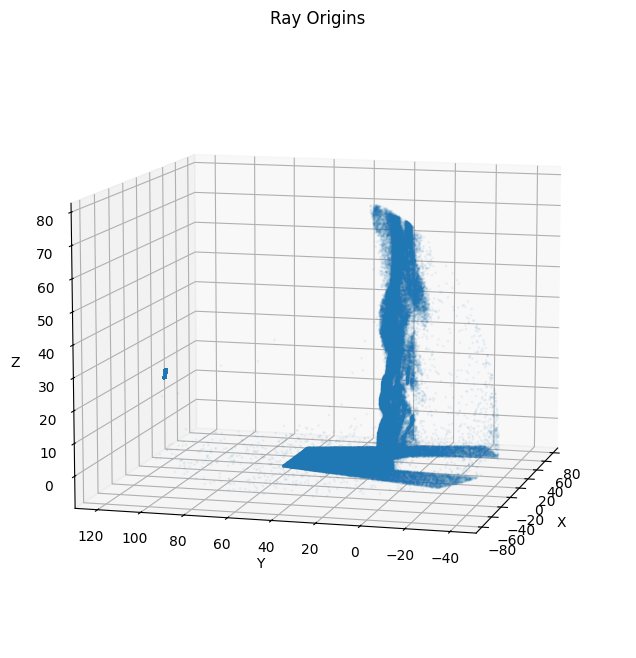

In [29]:
from mpl_toolkits.mplot3d import Axes3D


o_cpu = cp.asnumpy(random_batch['o'])

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=10, azim=195)
ax.scatter(o_cpu[:, 0], o_cpu[:, 1], o_cpu[:, 2], s=1, alpha=0.05)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ray Origins')

plt.show()


In [7]:


epsilon = 1e-3

L_target_gpu = cp.where(
    random_batch['beta'] > epsilon,
    random_batch['L_after'] / random_batch['beta'],
    0.0
)

L_target_gpu = L_target_gpu[cp.any(L_target_gpu > 0, axis=1)]
L_target_cpu = cp.asnumpy(L_target_gpu)

fig, axes = plt.subplots(figsize=(15, 4))

axes.hist(L_target_cpu[:, 0], bins=255, alpha=0.5, label='R', color='red', log=True)
axes.hist(L_target_cpu[:, 1], bins=255, alpha=0.5, label='G', color='green', log=True)
axes.hist(L_target_cpu[:, 2], bins=255, alpha=0.5, label='B', color='blue', log=True)

axes.set_xlabel('Value')
axes.set_ylabel('Log Count')
axes.set_title('L_target Distribution by Channel')
axes.legend()

plt.show()



KeyError: 'beta'

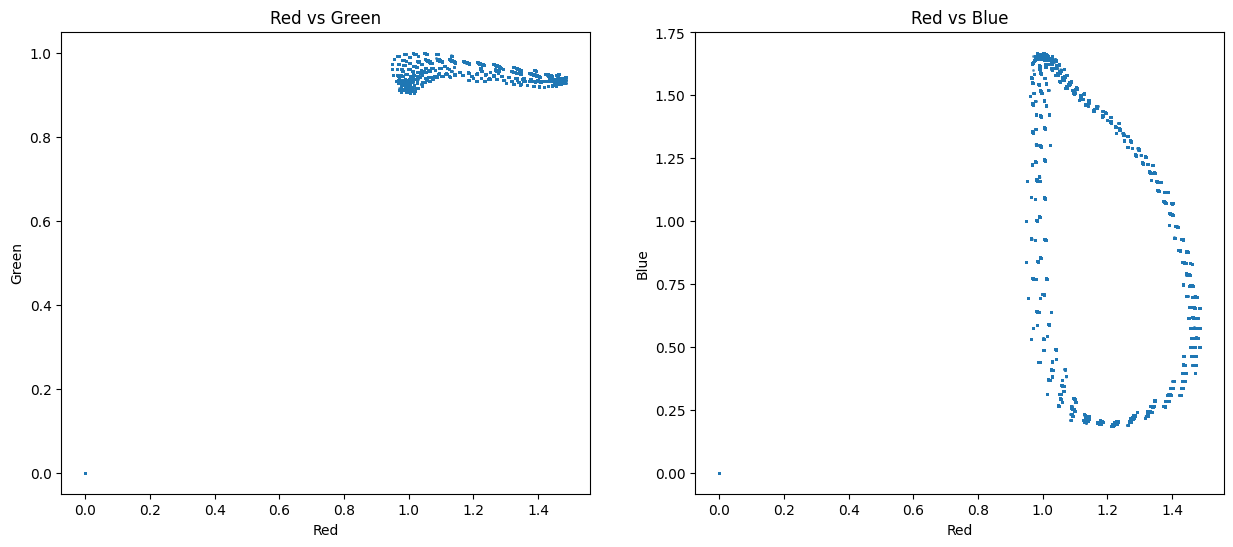

Entries where Red >= 1: 0 / 500000
[]


In [30]:



T_after_cpu = cp.asnumpy(random_batch['T_after'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# fig, axes = plt.subplots(figsize=(15, 4))

# axes.hist(T_after_cpu[:, 0], bins=100, alpha=0.5, label='R', color='red')
# axes.hist(T_after_cpu[:, 1], bins=100, alpha=0.5, label='G', color='green')
# axes.hist(T_after_cpu[:, 2], bins=100, alpha=0.5, label='B', color='blue')
# axes.hist(T_after_cpu[:, 3], bins=100, alpha=0.5, label='B', color='purple')



# axes.set_xlabel('Value')

# axes.set_ylabel('Count')
# axes.set_title('T_after_cpu Distribution by Channel')
# axes.legend()

axes[0].scatter(T_after_cpu[:, 0], T_after_cpu[:, 1], s=1, alpha=0.05)
axes[0].set_xlabel('Red')
axes[0].set_ylabel('Green')
axes[0].set_title('Red vs Green')

axes[1].scatter(T_after_cpu[:, 0], T_after_cpu[:, 2], s=1, alpha=0.05)
axes[1].set_xlabel('Red')
axes[1].set_ylabel('Blue')
axes[1].set_title('Red vs Blue')

plt.show()

# print(T_after_cpu)

# print(T_after_cpu[:100, 0])

high_red_mask = (T_after_cpu[:, 0] >= 1.0) & (T_after_cpu[:, 1] <= 0.01) & (T_after_cpu[:, 2] <= 0.01)
print(f"Entries where Red >= 1: {high_red_mask.sum()} / {len(T_after_cpu)}")
print(T_after_cpu[high_red_mask])


In [40]:
high_red_mask = (T_after_gpu[:, 0] >= 1.0) & (T_after_gpu[:, 1] >= 1.0) & (T_after_gpu[:, 2] >= 1.0)
print(f"Entries where Red >= 1: {high_red_mask.sum()} / {len(T_after_gpu)}")
print(T_after_gpu[high_red_mask])

Entries where Red >= 1: 0 / 20000000
[]


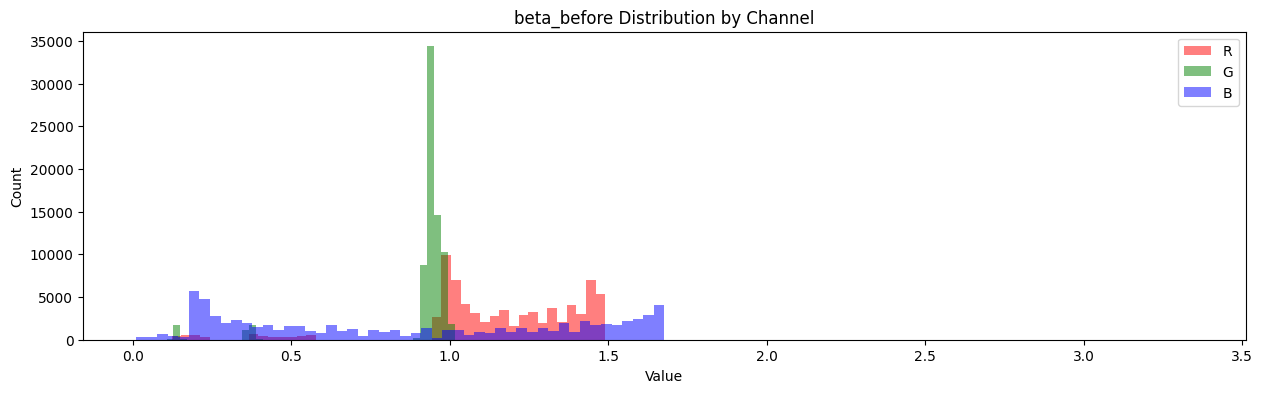

[[1.0004623  0.93710244 1.6601797 ]
 [1.0955329  0.98155564 0.29574123]
 [1.3742166  0.93371254 1.0783914 ]
 ...
 [0.54764    0.36300975 0.36350015]
 [1.093405   0.95163107 1.5164573 ]
 [1.0035932  0.9310169  1.0951031 ]]


In [19]:



beta_before = cp.asnumpy(random_batch['beta'])

fig, axes = plt.subplots(figsize=(15, 4))

axes.hist(beta_before[:, 0], bins=100, alpha=0.5, label='R', color='red')
axes.hist(beta_before[:, 1], bins=100, alpha=0.5, label='G', color='green')
axes.hist(beta_before[:, 2], bins=100, alpha=0.5, label='B', color='blue')

axes.set_xlabel('Value')

axes.set_ylabel('Count')
axes.set_title('beta_before Distribution by Channel')
axes.legend()

plt.show()

print(beta_before)


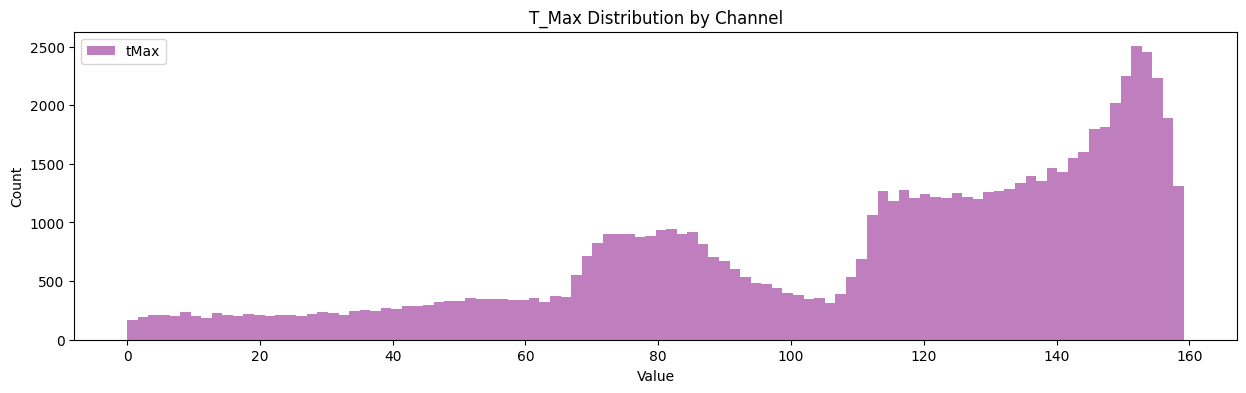

In [33]:
# TMax value distribution


tMax_cpu = cp.asnumpy(random_batch['tMax'])

tMax_fig, tMax_axes = plt.subplots(figsize=(15, 4))


tMax_axes.hist(tMax_cpu, bins=100, alpha=0.5, label='tMax', color='purple')


tMax_axes.set_xlabel('Value')

tMax_axes.set_ylabel('Count')
tMax_axes.set_title('T_Max Distribution by Channel')
tMax_axes.legend()

plt.show()



In [34]:
# TODO create a 3D plot to show rayDirections and potentially tMax as well
print(np.where(tMax_gpu[valid_mask] < 0)[0])


[]
